In [5]:
#Importing Library's
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
#Importing dataset
df = pd.read_csv('StudentsPerformance.csv')
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
# Get info about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [9]:
#Checking the null values
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [10]:
#Checking duplicate values
df.duplicated().sum()

np.int64(0)

In [11]:
#Gender check
df['gender'].unique()

array(['female', 'male'], dtype=object)

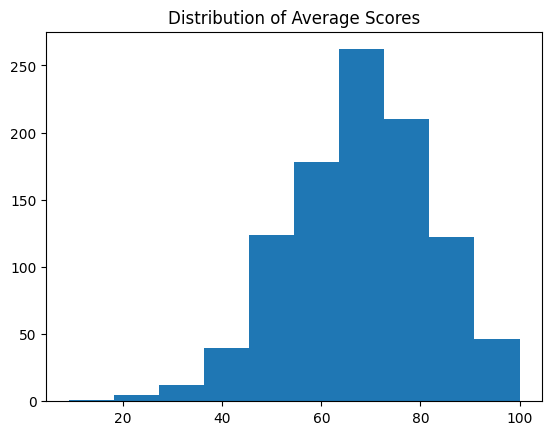

In [39]:
#Average score by Marks
df['average score'] = (df['math score'] + df['reading score'] + df['writing score']) / 3
plt.hist(df['average score'])
plt.title('Distribution of Average Scores')
plt.show()

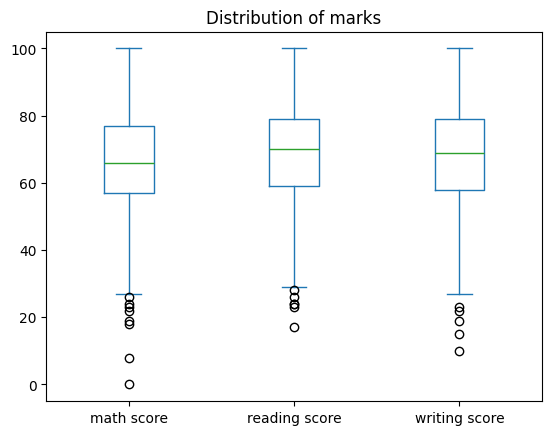

In [44]:
#Distrubution of marks
df[['math score', 'reading score', 'writing score']].plot(kind = 'box')
plt.title('Distribution of marks')
plt.show()

In [12]:
# checking types of parental education
df['parental level of education'].unique()

array(["bachelor's degree", 'some college', "master's degree",
       "associate's degree", 'high school', 'some high school'],
      dtype=object)

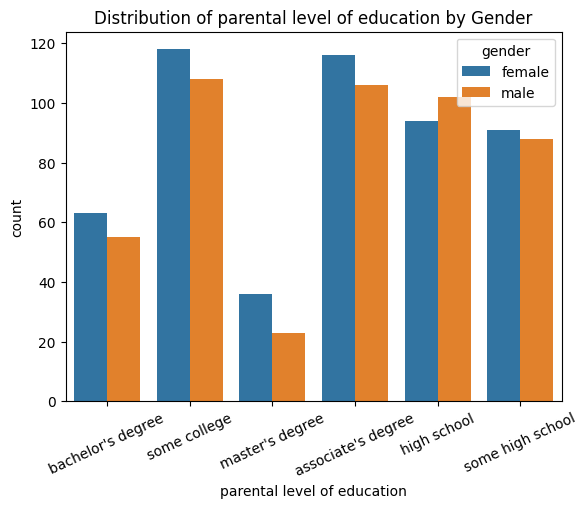

In [13]:
# Graphical representation of parental level by gender
sns.countplot(data=df, x='parental level of education', hue='gender')
plt.xlabel = 'parental level of education'
plt.ylabel = 'Number of Students'
plt.title('Distribution of parental level of education by Gender')
plt.xticks(rotation=25)
plt.show()

In [14]:
#race/ethnicity check
print(sorted(df['race/ethnicity'].unique()))

['group A', 'group B', 'group C', 'group D', 'group E']


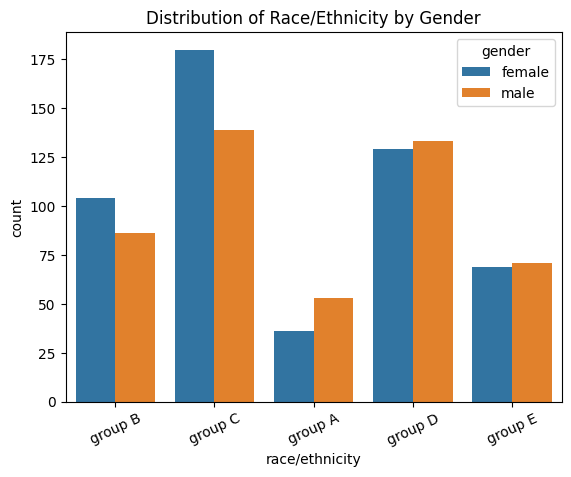

In [15]:
#Graphical representation of race/ethnicity
sns.countplot(data=df, x='race/ethnicity', hue='gender')
plt.xlabel = 'Race/Ethnicity'
plt.ylabel = 'Number of Students'
plt.title('Distribution of Race/Ethnicity by Gender')
plt.xticks(rotation=25)
plt.show()

In [16]:
#Overall Performence of Students by gender
over_per = df.groupby('gender')[['math score','reading score','writing score']].mean()
over_per

,math score,reading score,writing score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


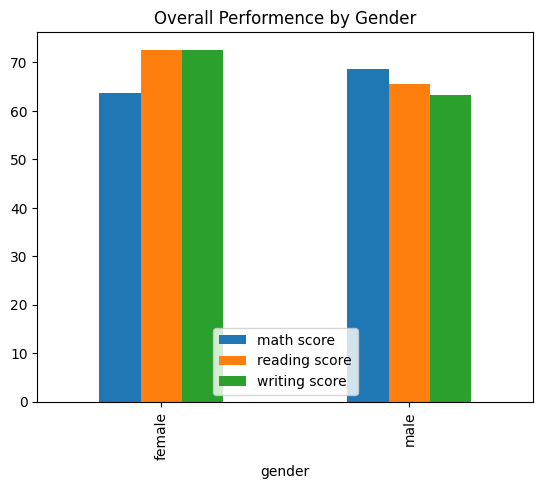

In [17]:
#Graphical representation of Overall Performence by gender
over_per.plot(kind='bar')
plt.xlabel = 'Gender'
plt.ylabel = 'Score'
plt.title('Overall Performence by Gender')
plt.show()

In [19]:
#Test Preparation count by gender
tpc = df.groupby('gender')[['test preparation course']].value_counts()
tpc

gender  test preparation course
female  none                       334
        completed                  184
male    none                       308
        completed                  174
Name: count, dtype: int64

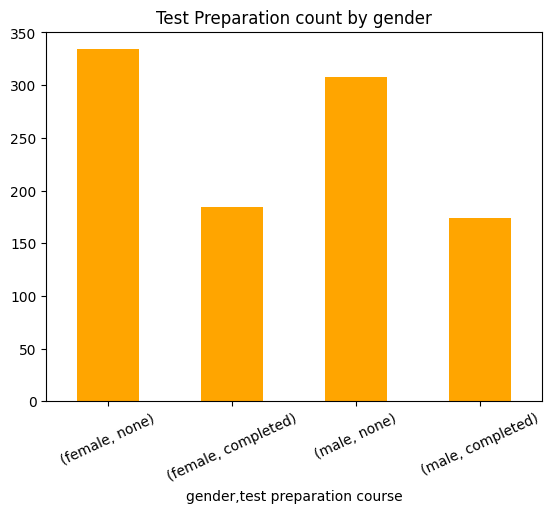

In [26]:
#Graphical Representation of Test Preparation count
tpc.plot(kind='bar', color = 'orange')
plt.xlabel = 'Gender'
plt.ylabel = 'Score'
plt.title('Test Preparation count by gender')
plt.xticks(rotation=25)
plt.show()

In [24]:
#Lunch Impect by Gender
lunch = df.groupby('gender')[['lunch']].value_counts()
lunch

gender  lunch       
female  standard        329
        free/reduced    189
male    standard        316
        free/reduced    166
Name: count, dtype: int64

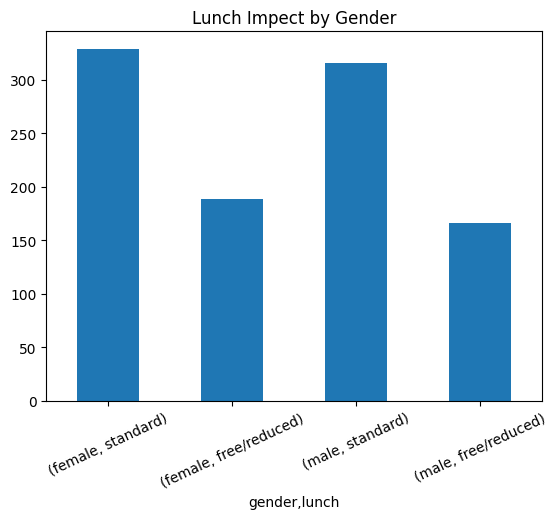

In [27]:
#Graphical Representation of Lunch Impect
lunch.plot(kind='bar')
plt.xlabel = 'Gender'
plt.ylabel = 'Score'
plt.title('Lunch Impect by Gender')
plt.xticks(rotation=25)
plt.show()

In [28]:
# Correlation by scores
corr = df[['math score', 'reading score', 'writing score']].corr()
corr

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


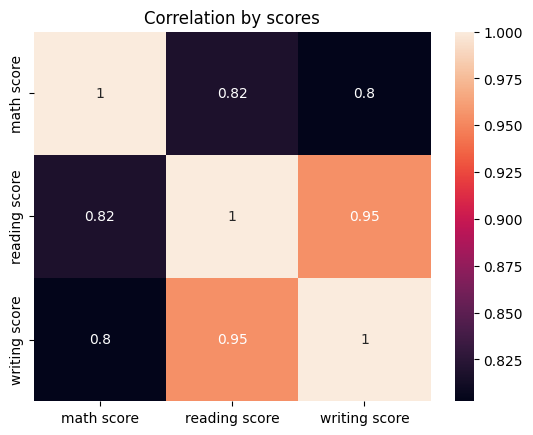

In [31]:
# Graphical Representation of Correlation by scores
sns.heatmap(corr, annot=True)
plt.title('Correlation by scores')
plt.show()